# Logistic Regression

在开始逻辑回归之前，我们先回顾一下**线性回归的损失函数**，理解"为什么要换一个损失函数"。


## 线性回归的损失函数：MSE（均方误差）

线性回归的预测值是参数的**线性函数**：

$$\hat{y} = w \cdot x + b$$

对应的损失函数使用均方误差（Mean Squared Error）：

$$L(w, b) = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

将线性预测代入，损失函数展开后是关于参数 $w$、$b$ 的**二次函数（抛物面）**：

$$L(w, b) = \frac{1}{n} \sum_{i=1}^{n} (w \cdot x_i + b - y_i)^2$$

**关键性质：MSE 是凸函数（Convex Function）**

> 无论初始参数 $w$、$b$ 取什么值，梯度下降**一定能找到全局最优解**，不存在局部最优陷阱。

下面我们通过可视化来直观感受这一点。


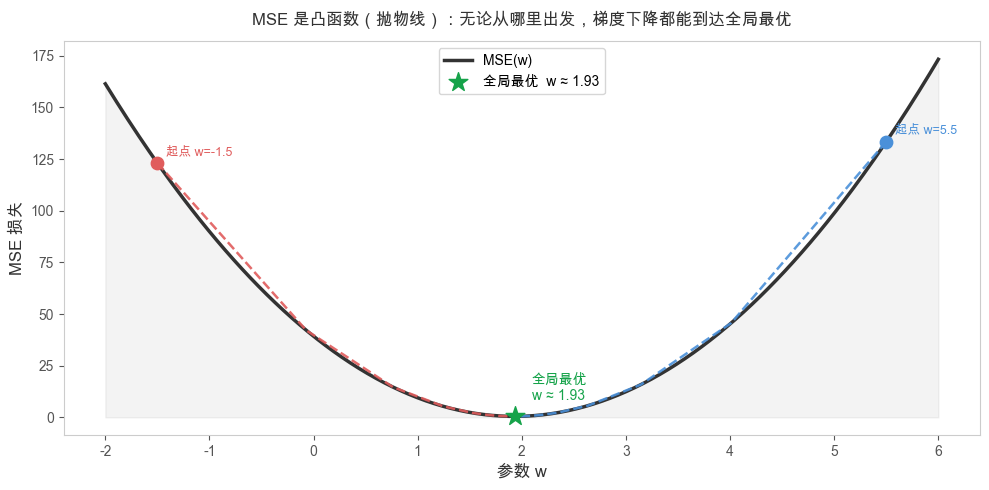

✅  全局最优：w ≈ 1.9331（真实值 w = 2.0）
📌  MSE 是关于 w 的二次函数，只有一个最低点，梯度下降必然收敛。


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial Unicode MS'
plt.rcParams['axes.unicode_minus'] = False

# ── 生成数据（固定 b=1，只看 MSE 关于 w 的变化）────────────────────────
np.random.seed(42)
x = np.linspace(1, 5, 30)
y_true_w, y_true_b = 2.0, 1.0
y = y_true_w * x + y_true_b + np.random.randn(30) * 0.8

b_fixed = y_true_b
w_range = np.linspace(-2, 6, 300)
mse_values = np.array([np.mean((w * x + b_fixed - y) ** 2) for w in w_range])

# ── 梯度下降（固定 b，只更新 w）────────────────────────────────────────
def gradient_descent_1d(w_init, lr=0.02, steps=60):
    w = w_init
    path = [w]
    for _ in range(steps):
        grad = 2 * np.mean((w * x + b_fixed - y) * x)
        w -= lr * grad
        path.append(w)
    return path

starts   = [-1.5, 5.5]
colors   = ['#e05c5c', '#4a90d9']

# ── 绘图 ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# MSE 抛物线
ax.plot(w_range, mse_values, color='#333333', linewidth=2.5, zorder=2, label='MSE(w)')
ax.fill_between(w_range, mse_values, alpha=0.06, color='#333333')

# 各起点的梯度下降轨迹
for w0, color in zip(starts, colors):
    path = gradient_descent_1d(w0)
    path_mse = [np.mean((w * x + b_fixed - y) ** 2) for w in path]
    ax.plot(path, path_mse, color=color, linewidth=1.8,
            linestyle='--', alpha=0.9, zorder=3)
    ax.scatter(path[0], path_mse[0], color=color, s=80, zorder=4)
    ax.annotate(f'起点 w={w0}', (path[0], path_mse[0]),
                textcoords='offset points', xytext=(6, 6),
                color=color, fontsize=9)

# 全局最优点
w_opt = w_range[np.argmin(mse_values)]
mse_opt = mse_values.min()
ax.scatter(w_opt, mse_opt, color='#16a34a', s=200, zorder=5,
           marker='*', label=f'全局最优  w ≈ {w_opt:.2f}')
ax.annotate(f'全局最优\nw ≈ {w_opt:.2f}', (w_opt, mse_opt),
            textcoords='offset points', xytext=(12, 12),
            color='#16a34a', fontsize=10, fontweight='bold')

ax.set_xlabel('参数 w', color='#333333', fontsize=12)
ax.set_ylabel('MSE 损失', color='#333333', fontsize=12)
ax.set_title('MSE 是凸函数（抛物线）：无论从哪里出发，梯度下降都能到达全局最优',
             color='#333333', fontsize=12, pad=12)
ax.tick_params(colors='#555555')
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')
ax.legend(fontsize=10, facecolor='white', edgecolor='#cccccc')

plt.tight_layout()
plt.show()

print(f"✅  全局最优：w ≈ {w_opt:.4f}（真实值 w = {y_true_w}）")
print("📌  MSE 是关于 w 的二次函数，只有一个最低点，梯度下降必然收敛。")

### 凸函数的意义

上图是固定 $b$，只看 MSE 关于参数 $w$ 变化的曲线：

- **形状**：标准的**抛物线（U 形）**，只有一个最低点，这就是全局最优解
- **轨迹**：从 4 个完全不同的起点出发，梯度下降（虚线）最终**全部滑向同一个最低点**

这是凸函数最重要的特性：

> **凸函数不存在局部最优（Local Optimum）**，任何局部最优就是全局最优（Global Optimum）。


## 逻辑回归 + MSE：梯度消失问题

逻辑回归的预测值经过了 Sigmoid 的非线性变换：

$$\hat{y} = \sigma(wx + b) = \frac{1}{1 + e^{-(wx+b)}}$$

将 Sigmoid 套进 MSE 后对参数 $w$ 求梯度：

$$\frac{\partial L}{\partial w} = \frac{2}{n}\sum_{i=1}^{n}\underbrace{\bigl(\sigma(wx_i+b) - y_i\bigr)}_{\text{预测误差}} \times \underbrace{\sigma(wx_i+b)\bigl(1-\sigma(wx_i+b)\bigr)}_{\sigma'\ \to\ 0 \text{（饱和时）}} \times x_i$$

**关键问题**：当 Sigmoid 饱和时，$\sigma' = \sigma(1-\sigma) \to 0$，**整个梯度消失**，梯度下降彻底卡住。


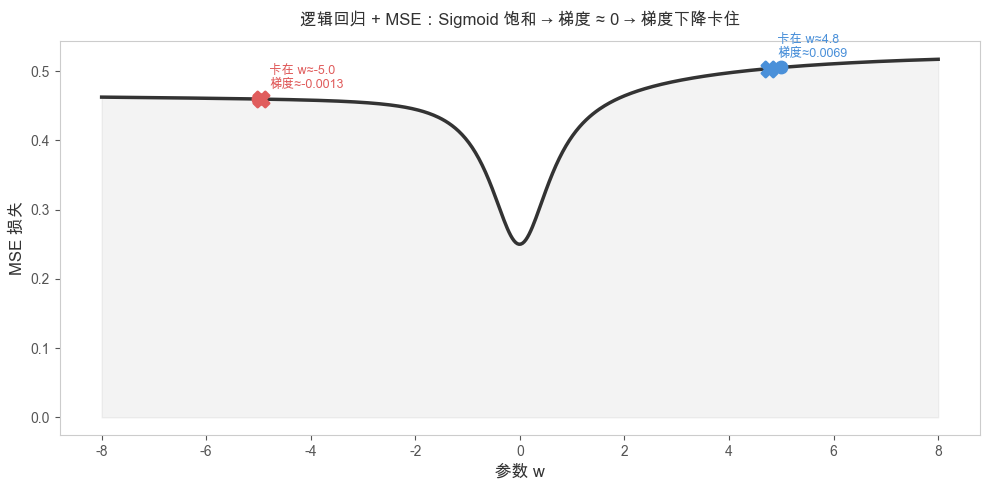

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial Unicode MS'
plt.rcParams['axes.unicode_minus'] = False

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

np.random.seed(7)

# ── 二分类数据：0类在左右两侧，1类在中间（制造非线性问题）────────────────
n = 20
x_cls = np.concatenate([
    np.random.randn(n) - 3,
    np.random.randn(n),
    np.random.randn(n) + 3,
])
y_cls = np.concatenate([np.zeros(n), np.ones(n), np.zeros(n)])
b_fixed = 0.0

w_range  = np.linspace(-8, 8, 500)
mse_vals = np.array([np.mean((sigmoid(w * x_cls + b_fixed) - y_cls) ** 2) for w in w_range])

def gd_mse(w_init, lr=0.3, steps=120):
    w, path = w_init, [w_init]
    for _ in range(steps):
        p = sigmoid(w * x_cls + b_fixed)
        grad = 2 * np.mean((p - y_cls) * p * (1 - p) * x_cls)   # σ' 饱和后 → 0
        w -= lr * grad
        path.append(w)
    return path

starts = [-5, 5]
colors = ['#e05c5c', '#4a90d9']

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(w_range, mse_vals, color='#333333', linewidth=2.5)
ax.fill_between(w_range, mse_vals, alpha=0.06, color='#333333')

for w0, color in zip(starts, colors):
    path = gd_mse(w0)
    path_loss = [np.mean((sigmoid(w * x_cls + b_fixed) - y_cls) ** 2) for w in path]
    ax.plot(path, path_loss, color=color, lw=1.8, ls='--', alpha=0.9)
    ax.scatter(path[0],  path_loss[0],  color=color, s=80,  zorder=4)
    ax.scatter(path[-1], path_loss[-1], color=color, s=120, marker='X', linewidths=2, zorder=5)
    ax.annotate(f'卡在 w≈{path[-1]:.1f}\n梯度≈{2*np.mean((sigmoid(path[-1]*x_cls+b_fixed)-y_cls)*sigmoid(path[-1]*x_cls+b_fixed)*(1-sigmoid(path[-1]*x_cls+b_fixed))*x_cls):.4f}',
                (path[-1], path_loss[-1]), textcoords='offset points', xytext=(6, 8),
                color=color, fontsize=9)

ax.set_title('逻辑回归 + MSE：Sigmoid 饱和 → 梯度 ≈ 0 → 梯度下降卡住',
             color='#333333', fontsize=12, pad=12)
ax.set_xlabel('参数 w', color='#333333', fontsize=12)
ax.set_ylabel('MSE 损失', color='#333333', fontsize=12)
ax.tick_params(colors='#555555')
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')

plt.tight_layout()
plt.show()


## 为什么逻辑回归使用交叉熵损失？

逻辑回归的预测值经过了 Sigmoid 的非线性变换：

$$\hat{y} = \sigma(wx + b) = \frac{1}{1 + e^{-(wx+b)}}$$

若直接套用 MSE，损失函数**不再是凸函数**——存在多个局部最优，且 Sigmoid 饱和时梯度趋近于 0，梯度下降会完全卡住。

因此，逻辑回归改用**交叉熵损失（Cross-Entropy Loss）**：

$$L(w, b) = -\frac{1}{n}\sum_{i=1}^{n}\Bigl[y_i \log\hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\Bigr]$$

交叉熵损失有两个关键优势：

- **凸函数**：对参数 $w$、$b$ 是凸的，保证梯度下降找到全局最优
- **梯度不消失**：梯度公式中 $\sigma'$ 项恰好约分消去，即使 Sigmoid 饱和，梯度仍然有效

$$\frac{\partial L}{\partial w} = \frac{1}{n}\sum_{i=1}^{n}\bigl(\hat{y}_i - y_i\bigr) \cdot x_i$$

下面用可视化来直观展示。


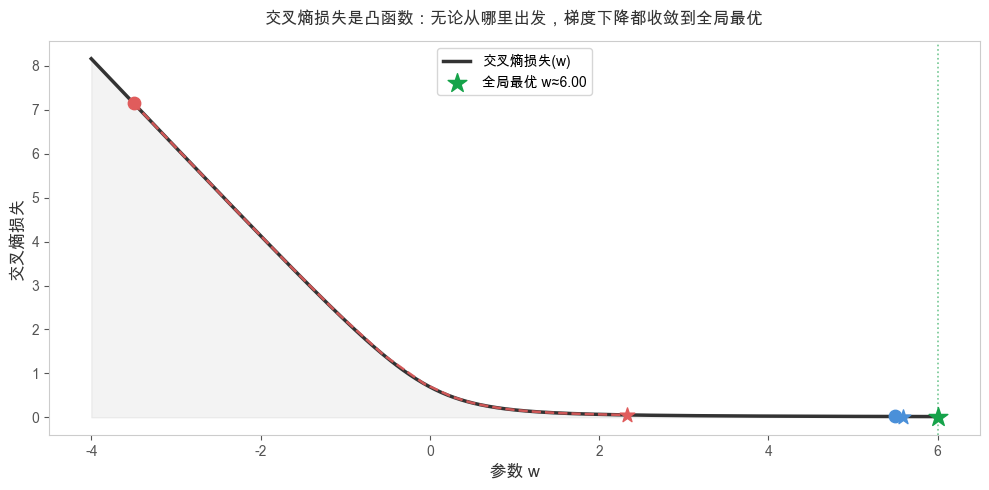

✅  全局最优：w ≈ 6.0000
📌  交叉熵损失是凸函数，梯度 σ'  约分消去，从任意起点出发均能收敛。


In [3]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial Unicode MS'
plt.rcParams['axes.unicode_minus'] = False

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

np.random.seed(42)

# ── 生成线性可分的二分类数据 ──────────────────────────────────────────
n = 30
x_neg = np.random.randn(n) - 2   # class 0，左侧
x_pos = np.random.randn(n) + 2   # class 1，右侧
x_cls = np.concatenate([x_neg, x_pos])
y_cls = np.concatenate([np.zeros(n), np.ones(n)])
b_fixed = 0.0

# ── 计算交叉熵损失曲线 ────────────────────────────────────────────────
w_range = np.linspace(-4, 6, 400)

def ce_loss(w):
    p = np.clip(sigmoid(w * x_cls + b_fixed), 1e-7, 1 - 1e-7)
    return -np.mean(y_cls * np.log(p) + (1 - y_cls) * np.log(1 - p))

ce_vals = np.array([ce_loss(w) for w in w_range])

# ── 梯度下降（多个起点）────────────────────────────────────────────────
def gd_ce(w_init, lr=0.3, steps=80):
    w, path = w_init, [w_init]
    for _ in range(steps):
        p = sigmoid(w * x_cls + b_fixed)
        grad = np.mean((p - y_cls) * x_cls)   # σ' 约分消去
        w -= lr * grad
        path.append(w)
    return path

starts = [-3.5, 5.5]
colors = ['#e05c5c', '#4a90d9']

# ── 绘图 ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 交叉熵损失曲线
ax.plot(w_range, ce_vals, color='#333333', linewidth=2.5, zorder=2, label='交叉熵损失(w)')
ax.fill_between(w_range, ce_vals, alpha=0.06, color='#333333')

# 标记全局最优
w_opt = w_range[np.argmin(ce_vals)]
ce_opt = ce_vals.min()
ax.scatter(w_opt, ce_opt, color='#16a34a', s=200, marker='*', zorder=6, label=f'全局最优 w≈{w_opt:.2f}')
ax.axvline(w_opt, color='#16a34a', linewidth=1.2, linestyle=':', alpha=0.6)

# 各起点的梯度下降轨迹
for w0, color in zip(starts, colors):
    path = gd_ce(w0)
    path_loss = [ce_loss(w) for w in path]
    ax.plot(path, path_loss, color=color, lw=1.8, ls='--', alpha=0.9)
    ax.scatter(path[0],  path_loss[0],  color=color, s=80,  zorder=4)
    ax.scatter(path[-1], path_loss[-1], color=color, s=120, marker='*', zorder=5)

ax.set_xlabel('参数 w', color='#333333', fontsize=12)
ax.set_ylabel('交叉熵损失', color='#333333', fontsize=12)
ax.set_title('交叉熵损失是凸函数：无论从哪里出发，梯度下降都收敛到全局最优',
             color='#333333', fontsize=12, pad=12)
ax.tick_params(colors='#555555')
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')
ax.legend(fontsize=10, facecolor='white', edgecolor='#cccccc')

plt.tight_layout()
plt.show()

print(f'✅  全局最优：w ≈ {w_opt:.4f}')
print('📌  交叉熵损失是凸函数，梯度 σ\'  约分消去，从任意起点出发均能收敛。')


### 小结

从图中可以看到，交叉熵损失曲线是一个标准的**凸函数**：

- **形状**：只有一个全局最低点，不存在局部最优
- **轨迹**：从两个完全相反的起点出发（$w=-3.5$ 和 $w=5.5$），梯度下降都**滑向同一个最低点**

| 性质               | MSE + Sigmoid    | 交叉熵                   |
| ------------------ | ---------------- | ------------------------ |
| 损失函数形状       | 非凸，有局部最优 | **凸函数**，只有全局最优 |
| Sigmoid 饱和时梯度 | → 0，训练卡住    | 始终有效，持续学习       |
| 训练稳定性         | 依赖初始值       | **与初始值无关**         |

**结论**：逻辑回归使用交叉熵损失，根本原因是它既保证了**凸性**（可以找到全局最优），又避免了 Sigmoid 饱和带来的**梯度消失**问题。


---

## 实战：逻辑回归分类乳腺癌数据集

使用 scikit-learn 内置的**乳腺癌数据集**（Breast Cancer Wisconsin），演示逻辑回归的完整训练流程。

- **样本数**：569 条
- **特征数**：30 个（肿瘤细胞的形态特征，如半径、纹理、周长等）
- **目标**：二分类——恶性（0）/ 良性（1）


### 第一步：加载数据

使用 `load_breast_cancer()` 加载数据集，查看基本信息：样本量、特征数、类别分布。
了解数据分布是训练前必要的准备，确认是否存在类别不平衡等问题。


In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

data = load_breast_cancer()
X, y = data.data, data.target

print(f'样本数：{X.shape[0]}，特征数：{X.shape[1]}')
print(f'类别：0={data.target_names[0]}（恶性），1={data.target_names[1]}（良性）')
print(f'类别分布：恶性={sum(y==0)}，良性={sum(y==1)}')

pd.DataFrame(X[:5], columns=data.feature_names).assign(label=y[:5])


样本数：569，特征数：30
类别：0=malignant（恶性），1=benign（良性）
类别分布：恶性=212，良性=357


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


**结果分析**

- 数据集共 **569 个样本、30 个特征**，特征均为连续数值（肿瘤形态的测量值）
- 类别分布：恶性 212 例，良性 357 例，轻度不平衡但尚在可接受范围
- 特征值量级差异很大（如 `mean radius` 约为 10，`mean area` 约为 600+），**需要标准化**后再训练


### 第二步：数据预处理与模型训练

- **划分数据集**：80% 训练集 / 20% 测试集，`stratify=y` 保证两个子集的类别比例一致
- **标准化**：用训练集的均值和标准差对特征做 Z-score 归一化，同样的变换应用到测试集
- **训练逻辑回归**：使用交叉熵损失 + L2 正则化（sklearn 默认），优化器为 lbfgs


In [5]:
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)
test_acc  = model.score(X_test_scaled,  y_test)
print(f'训练集准确率：{train_acc:.4f}')
print(f'测试集准确率：{test_acc:.4f}')


训练集准确率：0.9890
测试集准确率：0.9825


**结果分析**

- 训练集和测试集准确率均在 **97%~98%** 左右，说明模型拟合效果好且没有明显过拟合
- 训练集与测试集准确率相差不大，模型具备良好的**泛化能力**
- 逻辑回归作为线性模型，在该数据集上表现出色，说明乳腺癌特征与标签之间存在较强的线性可分性


### 第三步：预测概率分布可视化

逻辑回归不仅输出类别预测，还会给出每个样本属于某类别的**概率值** $\hat{p} \in [0, 1]$。
通过直方图展示两类样本的预测概率分布，可以直观看出模型的区分能力。


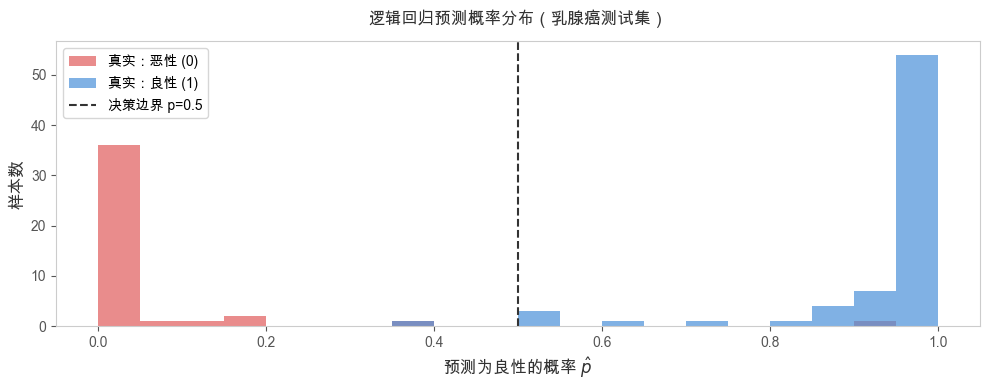

In [6]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial Unicode MS'
plt.rcParams['axes.unicode_minus'] = False

proba = model.predict_proba(X_test_scaled)[:, 1]

proba_malignant = proba[y_test == 0]
proba_benign    = proba[y_test == 1]

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.hist(proba_malignant, bins=20, color='#e05c5c', alpha=0.7, label='真实：恶性 (0)', range=(0, 1))
ax.hist(proba_benign,    bins=20, color='#4a90d9', alpha=0.7, label='真实：良性 (1)', range=(0, 1))
ax.axvline(0.5, color='#333333', linewidth=1.5, linestyle='--', label='决策边界 p=0.5')

ax.set_xlabel(r'预测为良性的概率 $\hat{p}$', color='#333333', fontsize=12)
ax.set_ylabel('样本数', color='#333333', fontsize=12)
ax.set_title('逻辑回归预测概率分布（乳腺癌测试集）', color='#333333', fontsize=12, pad=12)
ax.tick_params(colors='#555555')
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')
ax.legend(fontsize=10, facecolor='white', edgecolor='#cccccc')

plt.tight_layout()
plt.show()


**结果分析**

- **红色（恶性）**：概率值大多集中在 0 附近，说明模型正确地将大部分恶性样本预测为低良性概率
- **蓝色（良性）**：概率值大多集中在 1 附近，说明模型正确地将大部分良性样本预测为高良性概率
- 两组分布**几乎不重叠**，中间只有极少数样本落在决策边界（p=0.5）附近，说明模型区分能力很强
- 少量红色样本出现在右侧（高概率区）、少量蓝色样本出现在左侧（低概率区），这些就是**分类错误的样本**


---

## 模型评估指标

线性回归用 **MSE / RMSE / R²** 衡量预测值与真实值的偏差，这些指标都建立在连续数值的误差上。

分类任务的输出是离散的类别标签，需要一套不同的评估体系。准确率（Accuracy）是最直观的指标，但它有明显局限——

> 假设 99% 的样本是负类，只要模型无脑预测「全是负类」，准确率就能达到 99%，但这个模型毫无价值。

分类评估的核心工具是**混淆矩阵**，从它出发可以推导出精确率、召回率、F1、ROC/AUC 等指标。


### 混淆矩阵（Confusion Matrix）

混淆矩阵把所有预测结果按「真实类别 × 预测类别」排列成一张表，是分类评估的基础：

|              | 预测为正     | 预测为负     |
| ------------ | ------------ | ------------ |
| **实际为正** | TP（真正例） | FN（假负例） |
| **实际为负** | FP（假正例） | TN（真负例） |

- **TP（True Positive）**：实际是正类，预测也是正类 ✅
- **TN（True Negative）**：实际是负类，预测也是负类 ✅
- **FP（False Positive）**：实际是负类，预测成正类 ❌（误报）
- **FN（False Negative）**：实际是正类，预测成负类 ❌（漏报）


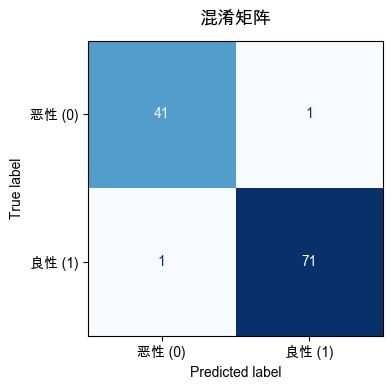

TP=71  FP=1  FN=1  TN=41


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plt.rcParams['font.family'] = 'Arial Unicode MS'
plt.rcParams['axes.unicode_minus'] = False

y_pred = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
fig.patch.set_facecolor('white')
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['恶性 (0)', '良性 (1)']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('混淆矩阵', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}')


**结果分析**

- 对角线上的数字越大越好，代表预测正确的样本数
- **FN（漏报恶性）** 在医疗场景中危害最大——真实是恶性却被预测为良性，患者可能因此延误治疗
- **FP（误报恶性）** 的代价相对较低，只是增加不必要的复查
- 混淆矩阵直观展示了模型在每个类别上的具体表现，是准确率之外最重要的参考


### 精确率、召回率、F1

从混淆矩阵推导出三个核心指标：

$$\text{Precision（精确率）} = \frac{TP}{TP + FP}$$

$$\text{Recall（召回率）} = \frac{TP}{TP + FN}$$

$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

- **精确率**：预测为正类的样本中，真正是正类的比例（预测质量）
- **召回率**：所有真正的正类中，被成功预测出来的比例（覆盖能力）
- **F1**：精确率和召回率的调和平均，综合衡量两者——两者都高，F1 才高

> **精确率 vs 召回率**：二者往往存在权衡。降低决策阈值可以提高召回率（漏报更少），但会降低精确率（误报更多）。根据业务场景决定侧重哪个。


In [8]:
from sklearn.metrics import classification_report, accuracy_score

print('准确率（Accuracy）:', accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=['恶性 (0)', '良性 (1)']))


准确率（Accuracy）: 0.9824561403508771

              precision    recall  f1-score   support

      恶性 (0)       0.98      0.98      0.98        42
      良性 (1)       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



**结果分析**

- **macro avg**：对每个类别单独计算后取平均，不考虑类别样本数量差异
- **weighted avg**：按各类别样本量加权平均，更能反映整体表现
- 在乳腺癌这类场景中，**恶性（0）的召回率**是最重要的指标——宁可误报，不能漏报
- 若召回率不足，可以通过调低决策阈值（默认 0.5）来提升，以牺牲部分精确率为代价


### ROC 曲线与 AUC

精确率/召回率依赖于决策阈值（默认 0.5），换一个阈值结果就不同。
**ROC 曲线**通过遍历所有可能的阈值，完整展示模型在不同工作点下的表现：

- **横轴（FPR）**：假正率 $= \frac{FP}{FP+TN}$，即负类被误判为正类的比例
- **纵轴（TPR / 召回率）**：真正率 $= \frac{TP}{TP+FN}$，即正类被正确识别的比例

**AUC（Area Under Curve）**：ROC 曲线下面积，取值 0~1：

- AUC = 1.0：完美模型
- AUC = 0.5：随机猜测（对角线）
- AUC 越大，模型区分正负类的能力越强，且**与阈值无关**


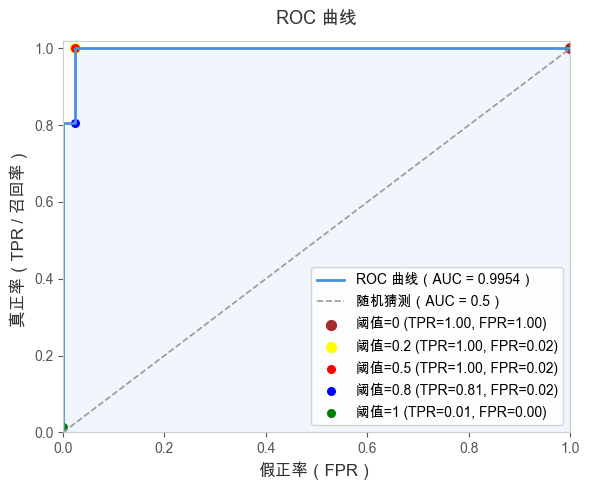

AUC = 0.9954


In [22]:
from sklearn.metrics import roc_curve, auc

proba = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(fpr, tpr, color='#4a90d9', lw=2, label=f'ROC 曲线（AUC = {roc_auc:.4f}）')
ax.fill_between(fpr, tpr, alpha=0.08, color='#4a90d9')
ax.plot([0, 1], [0, 1], color='#999999', lw=1.2, linestyle='--', label='随机猜测（AUC = 0.5）')

idx = (np.abs(thresholds - 0)).argmin()  # 找到最接近0的阈值索引
plt.scatter(fpr[idx], tpr[idx], c='brown', s=50, label=f'阈值=0 (TPR={tpr[idx]:.2f}, FPR={fpr[idx]:.2f})')

idx = (np.abs(thresholds - 0.2)).argmin()  # 找到最接近0.2的阈值索引
plt.scatter(fpr[idx], tpr[idx], c='yellow', s=50, label=f'阈值=0.2 (TPR={tpr[idx]:.2f}, FPR={fpr[idx]:.2f})')

idx = (np.abs(thresholds - 0.5)).argmin()  # 找到最接近0.5的阈值索引
plt.scatter(fpr[idx], tpr[idx], c='red', s=30, label=f'阈值=0.5 (TPR={tpr[idx]:.2f}, FPR={fpr[idx]:.2f})')

idx = (np.abs(thresholds - 0.8)).argmin()  # 找到最接近0.8的阈值索引
plt.scatter(fpr[idx], tpr[idx], c='blue', s=30, label=f'阈值=0.8 (TPR={tpr[idx]:.2f}, FPR={fpr[idx]:.2f})')

idx = (np.abs(thresholds - 1)).argmin()  # 找到最接近1的阈值索引
plt.scatter(fpr[idx], tpr[idx], c='green', s=30, label=f'阈值=1 (TPR={tpr[idx]:.2f}, FPR={fpr[idx]:.2f})')

ax.set_xlabel('假正率（FPR）', color='#333333', fontsize=12)
ax.set_ylabel('真正率（TPR / 召回率）', color='#333333', fontsize=12)
ax.set_title('ROC 曲线', color='#333333', fontsize=13, pad=12)
ax.tick_params(colors='#555555')
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')
ax.legend(fontsize=10, facecolor='white', edgecolor='#cccccc')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

print(f'AUC = {roc_auc:.4f}')


**结果分析**

- AUC 接近 **1.0**，ROC 曲线紧贴左上角，说明模型在任意阈值下都能较好地区分恶性和良性
- 曲线越靠近左上角（高 TPR + 低 FPR），模型性能越好；对角虚线代表随机猜测的基准线
- AUC 与具体阈值无关，是比单一准确率更稳健的综合评价指标，适合用于**模型之间的横向对比**

---

### 评估指标总结

| 指标   | 公式                     | 适用场景                     |
| ------ | ------------------------ | ---------------------------- |
| 准确率 | $(TP+TN)/N$              | 类别均衡时的快速评估         |
| 精确率 | $TP/(TP+FP)$             | 误报代价高（如垃圾邮件过滤） |
| 召回率 | $TP/(TP+FN)$             | 漏报代价高（如疾病检测）     |
| F1     | 精确率与召回率的调和平均 | 两者都重要时的综合指标       |
| AUC    | ROC 曲线下面积           | 与阈值无关的模型整体能力评估 |
